## Preliminares

In [1]:
# Importar modulos y funciones necesarias
import pandas as pd
import numpy as np
import os
from datetime import datetime
from sklearn.model_selection import cross_val_score, GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from category_encoders import TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import plotly.express as px
import matplotlib.pyplot as plt
import shap
from src.funcionesTransform import obtener_cols_financieras
from src.funcionesModeling import *

In [2]:
# Abrir archivo clean_data
data_folder = "data"
df = pd.read_parquet(f"{data_folder}/clean_data.parquet")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18028 entries, 0 to 18027
Data columns (total 54 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   CashAndCashEquivalents  18028 non-null  float64       
 1   CurrentDebt             18028 non-null  float64       
 2   LongTermDebt            18028 non-null  float64       
 3   TotalDebt               18028 non-null  float64       
 4   StockholdersEquity      18028 non-null  float64       
 5   TotalAssets             18028 non-null  float64       
 6   CurrentAssets           18028 non-null  float64       
 7   CurrentLiabilities      18028 non-null  float64       
 8   OperatingCashFlow       18028 non-null  float64       
 9   InvestingCashFlow       18028 non-null  float64       
 10  FinancingCashFlow       18028 non-null  float64       
 11  FreeCashFlow            18028 non-null  float64       
 12  CapitalExpenditure      18028 non-null  float6

## Feature Engineering

Sección para crear variables en la fase de modelado. 
La mayor parte de las variables fue creada en la fase de transformación.

In [3]:
# Calcular las aceleraciones netas (Momento - Tendencia) para variables de crecimiento.
# Una vez calculadas, se eliminan las variables trimestrales (reemplazar=True)
variables_de_crecimiento = ['Revenue_QoQ', 'Ebitda_QoQ', 'Fcf_QoQ', 'CapEx_QoQ']
df = calcular_acceleration_features(df, variables_de_crecimiento, reemplazar= True)

In [4]:
# Variable flag: empresas con patrimonio negativo
df['IsNegativeEquity'] = (df['StockholdersEquity'] < 0).astype(int)

In [5]:
# Sectores poco significativos: se agrupan en la categoria "Other"
# Se saltea en la versión actual
#sectores_importantes = ['InformationTechnology', 'Energy']

#df['Sector'] = np.where(df['Sector'].isin(sectores_importantes), df['Sector'], 'Other')

# Se vuelve a convertir en category
#df['Sector'] = df['Sector'].astype('category')

# Modelo de ensamblado de árboles RandomForest

In [6]:
# Se asegura el ordenamiento por fecha
df.sort_values(by='Date', inplace=True)

# Eliminar predictores
cols_financieras = obtener_cols_financieras()
variables_no_significativas = [
    'MonthlyReturn',
    'MarketCovariance',
    'Dividends',
    'IsNegativeEquity',
    'MonthlyVariance',
    'Ebitda_YoY',
    'CapEx_Acceleration',
    'Fcf_Acceleration'
]

predictores_a_eliminar = cols_financieras + variables_no_significativas + [
    # Ticker y fecha
    'Ticker',
    'Date',
    # Totales del mercado
    'TotalMarketAssets',
    'TotalMarketRevenue',
    # Variables que dependen del precio (posibles labels)
    'PriceToBook', 
    'TrailingPE',
    'EnterpriseToEbitda', 
    'Close',
    'MarketCap',
    'EnterpriseValue'  
    ]

# Se define la variable objetivo y las variables predictoras
label = 'Close'
X = df.drop(columns=predictores_a_eliminar) 
y = df[label]

# Columnas numéricas: 
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()

# Variables categóricas:
categorical_cols = ['Sector']

# preprocesador: escala numéricas y codifica categóricas
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', TargetEncoder(smoothing= 10.0), categorical_cols)
])

pipe = Pipeline([
    ('pre', preprocessor),
    ('model', RandomForestRegressor(
        random_state=42,
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=10,
        max_features='sqrt',
        max_samples= 0.8,
        min_samples_split= 10         
        ))
])

print("Entrenando el modelo con datos completos...")
pipe.fit(X, y)
r2_completo = pipe.score(X, y)
print(f"Entrenamiento finalizado. R2 en datos completos: {r2_completo:.4f}")

Entrenando el modelo con datos completos...
Entrenamiento finalizado. R2 en datos completos: 0.9308


In [7]:
# Test de validación cruzada
# Configurar el validador de series temporales
tscv = TimeSeriesSplit(n_splits=5) # n_splits=5 creará 5 particiones temporales secuenciales

# 3. Test de validación cruzada temporal
cross_val_scores = cross_val_score(
    estimator=pipe, 
    X=X, 
    y=y, 
    cv=tscv,         
    scoring='r2',
    n_jobs=-1        
)

print(f"R² promedio Time Series CV: {cross_val_scores.mean():.4f} ± {cross_val_scores.std():.4f}")

R² promedio Time Series CV: 0.5927 ± 0.1723


In [8]:
# Importancia de factores en el modelo
rf_model = pipe.named_steps['model']
importances = rf_model.feature_importances_

# Obtener los nombres de las características después del preprocesamiento
preprocessor = pipe.named_steps['pre']
feature_names = preprocessor.get_feature_names_out()

feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)
feature_importance_df.head(20)

,feature,importance
10,num__CapExToRevenue,0.194339
3,num__ReturnOnAssets,0.111403
4,num__DebtToEquity,0.082159
12,num__CurrentRatio_log,0.079512
13,num__RelativeAssets_log,0.078114
8,num__NetDebtToEbitda,0.069576
2,num__ReturnOnEquity,0.055087
17,cat__Sector,0.050231
14,num__RelativeRevenue_log,0.048348
1,num__ProfitMargins,0.045092


In [9]:
feature_importance_df.tail(10)

,feature,importance
14,num__RelativeRevenue_log,0.048348
1,num__ProfitMargins,0.045092
11,num__YearsSinceAdded,0.042385
0,num__OperatingMargins,0.037400
9,num__FcfToEbitda,0.025711
15,num__Revenue_Acceleration,0.017913
7,num__CapEx_YoY,0.017725
5,num__Revenue_YoY,0.016967
6,num__Fcf_YoY,0.014357
16,num__Ebitda_Acceleration,0.013680


## Aplicacion del modelo

Se generan 2 clusters segun las predicciones:
* Positive_Bias: si los residuos son mayores o iguales a cero.
* Negative_Bias: si los residuos son menores a cero.

In [10]:
# Se dividen los datos para predecir el valor de la última fecha disponible para cada ticker en el conjunto de test
X_train = X.iloc[:-len(df['Ticker'].unique())]  # Todos menos la última fecha de cada ticker
y_train = y.iloc[:-len(df['Ticker'].unique())]
X_test = X.iloc[-len(df['Ticker'].unique()):]   # Solo la última fecha de cada ticker
y_test = y.iloc[-len(df['Ticker'].unique()):]

# Recuperar el ticker usando el indice de y_test
tickers_test = df.loc[y_test.index, 'Ticker']

# Predicciones en el conjunto de test
y_pred = pipe.predict(X_test)

# Consolidar resultados individuales en un DataFrame
resultados_df = pd.DataFrame({
    'Ticker': tickers_test,
    'Predicted': y_pred,
    'Observed': y_test
})

# Calcular el residuo para cada predicción
resultados_df['Residuals'] = resultados_df['Predicted'] - resultados_df['Observed']

# Agrupar por ticker
resultados_agrupados = resultados_df.groupby('Ticker')[['Predicted', 'Observed', 'Residuals']].mean()

# Generar el Cluster sobre el promedio de los residuos
resultados_agrupados['Cluster'] = ['PositiveBias' if r >= 0 else 'NegativeBias' 
                                   for r in resultados_agrupados['Residuals']]

# Visualizar
fig = px.scatter(
    resultados_agrupados, 
    x='Observed', 
    y='Predicted', 
    color='Cluster',
    hover_name=resultados_agrupados.index, 
    labels={'Observed':'Valores Reales', 'Predicted':'Predicciones', 'Cluster':'Sesgo del Modelo'},
    title='Predicciones vs Reales (Agrupado por Ticker)'
)

# Línea de identidad perfecta
min_val = resultados_agrupados['Observed'].min()
max_val = resultados_agrupados['Observed'].max()
fig.add_shape(type='line', x0=min_val, y0=min_val, x1=max_val, y1=max_val,
              line=dict(color='black', dash='dash', width=2))
fig.show()

# Estadísticas por cluster a nivel Ticker
over_mask = resultados_agrupados['Cluster'] == 'PositiveBias'
under_mask = resultados_agrupados['Cluster'] == 'NegativeBias'

print("\nEstadísticas por cluster (a nivel de Ticker):")
print(f"Overprediction: {over_mask.sum()} tickers, residuo medio global: {resultados_agrupados.loc[over_mask, 'Residuals'].mean():.4f}")
print(f"Underprediction: {under_mask.sum()} tickers, residuo medio global: {resultados_agrupados.loc[under_mask, 'Residuals'].mean():.4f}")


Estadísticas por cluster (a nivel de Ticker):
Overprediction: 241 tickers, residuo medio global: 58.1044
Underprediction: 214 tickers, residuo medio global: -146.1321


In [11]:
# Ordenar resultados por residuos
resultados_agrupados = resultados_agrupados.sort_values(by='Residuals', ascending=False)

# Establer Ticker como columna para exportar resultados
resultados_agrupados.reset_index(inplace=True)

# Cálculo del error en porcentaje
resultados_agrupados['PercentError'] = ((resultados_agrupados['Predicted'] - resultados_agrupados['Observed'])/ resultados_agrupados['Observed'])*100

resultados_agrupados.drop(columns=['Predicted', 'Observed', 'Residuals'], inplace=True)

print(resultados_agrupados.head().to_string(index=False))

Ticker      Cluster  PercentError
  ORLY PositiveBias    394.162474
   BSX PositiveBias    422.691538
   GEN PositiveBias    794.952042
  VLTO PositiveBias    229.754088
   BMY PositiveBias    320.453424


In [12]:
# Se genera el reporte final para research posterior
# Se filtra df para mantener solo la fila más reciente de cada empresa
df_latest = df.drop_duplicates(subset=['Ticker'], keep='last')

df_reporte = resultados_agrupados.merge(df_latest, how='left', on='Ticker') 

dia = datetime.now().day
mes = datetime.now().month
year = datetime.now().year

os.makedirs(f"{data_folder}/reports", exist_ok=True) # Crear carpeta si no existe

df_reporte.to_csv(f"{data_folder}/reports/{year}_{mes}_{dia}.csv", index=False)
print(f'Reporte exportado en la carpeta {data_folder}/reports.')
df_reporte.head()

Reporte exportado en la carpeta data/reports.


,Ticker,Cluster,PercentError,CashAndCashEquivalents,CurrentDebt,LongTermDebt,TotalDebt,StockholdersEquity,TotalAssets,CurrentAssets,...,MarketCovariance,YearsSinceAdded,CurrentRatio_log,RelativeAssets_log,RelativeRevenue_log,Revenue_Acceleration,Ebitda_Acceleration,Fcf_Acceleration,CapEx_Acceleration,IsNegativeEquity
0,ORLY,PositiveBias,394.162474,0.193793,2.474595,6.016904,8.491499,-0.763352,16.538253,6.744277,...,0.000474,17.0,-0.263306,-7.338974,-6.817090,-0.064230,-0.068663,0.213141,0.141862,1
1,BSX,PositiveBias,422.691538,1.965000,0.299000,11.012000,11.436000,24.232000,43.673000,8.794000,...,0.000536,31.0,0.480474,-6.367920,-6.695851,-0.198643,-0.322896,-0.437610,0.055832,0
2,GEN,PositiveBias,794.952042,0.402000,0.181000,8.015000,8.260000,2.611000,15.589000,1.081000,...,0.002355,23.0,-0.919062,-7.398085,-8.085839,-0.270628,-0.269754,-0.261139,0.466424,0
3,VLTO,PositiveBias,229.754088,2.031000,0.700000,1.973000,2.879000,3.105000,7.693000,3.432000,...,0.000319,3.0,0.512381,-8.104339,-7.989983,-0.059676,-0.054579,-0.234872,0.145212,0
4,BMY,PositiveBias,320.453424,10.209000,2.261000,42.850000,47.139000,18.473000,90.038000,29.390000,...,-0.000646,69.0,0.227192,-5.644419,-5.820021,0.002118,-0.621380,0.078117,0.050238,0


## Explicabilidad del Modelo (SHAP)

In [16]:
# Seleccionar un Ticker específico a evaluar
ticker_a_explicar = 'MSCI'

--- Explicación de la predicción para: MSCI ---


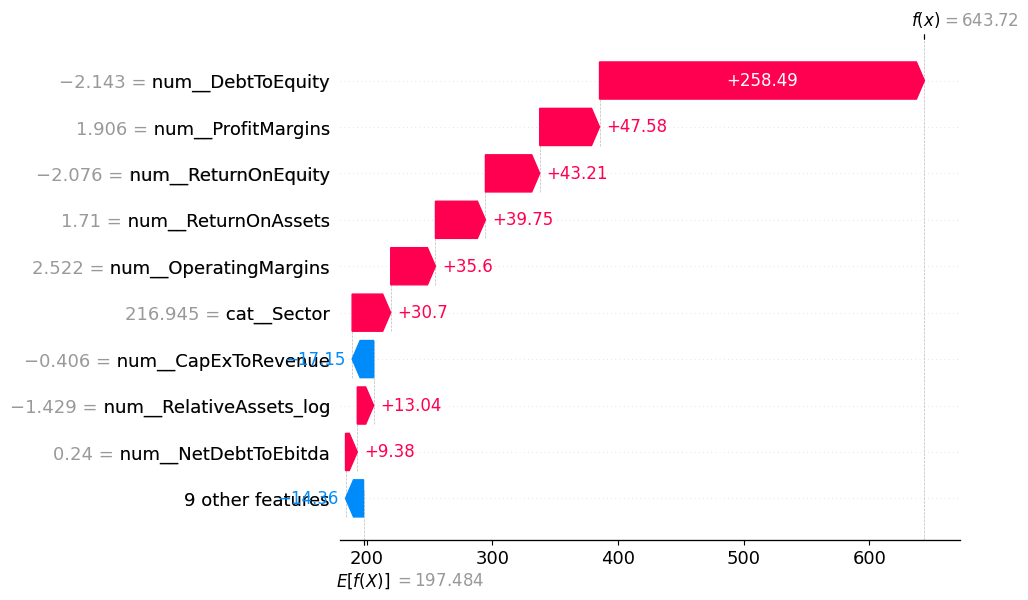

In [17]:
# Extraer los componentes del pipeline
preprocessor = pipe.named_steps['pre']
rf_model = pipe.named_steps['model']

# Transformar los datos de test (X_test) usando el preprocesador
X_test_transformed = preprocessor.transform(X_test)

# Obtener los nombres de las columnas transformadas
feature_names = preprocessor.get_feature_names_out()

# Crear un DataFrame con los datos transformados para que SHAP lea los nombres
X_test_shap = pd.DataFrame(X_test_transformed, columns=feature_names, index=X_test.index)

# Verificar que el ticker esté en los datos de test
if ticker_a_explicar in tickers_test.values:
    # Obtener la posición (índice entero) del ticker en el array de test
    idx = np.where(tickers_test == ticker_a_explicar)[0][0]
    
    # Extraer solo la fila del ticker seleccionado
    X_ticker_eval = X_test_shap.iloc[[idx]]
    
    # Inicializar el explicador de SHAP
    explainer = shap.TreeExplainer(rf_model)
    
    # Calcular los valores SHAP (solo para el ticker seleccionado para optimizar tiempo)
    shap_values = explainer(X_ticker_eval)
    
    print(f"--- Explicación de la predicción para: {ticker_a_explicar} ---")
    
    # Crear la figura y visualizar
    plt.figure(figsize=(10, 6))
    
    # Generar el gráfico de cascada (Waterfall plot)
    shap.plots.waterfall(shap_values[0], max_display=10)
    
else:
    print(f"El ticker {ticker_a_explicar} no se encuentra en el conjunto de test (tickers_test).")

## Anexo: optimización de hiperparámetros

In [15]:
ejecutar_celda = False

if ejecutar_celda:
    nombre_modelo = "Random Forest"
    print(f"Configurando GridSearchCV para {nombre_modelo}")

    # Pipeline usando el preprocesador específico para Random Forest
    modelo_base = Pipeline(steps=[
        ('preprocesador', preprocessor),
        ('rf', RandomForestRegressor(random_state=42))
    ])

    param_grid = {
        'rf__n_estimators': [300],
        'rf__max_depth': [10],
        'rf__min_samples_leaf': [10],
        'rf__min_samples_split': [10],
        'rf__max_samples': [0.8],
        'rf__max_features': ['sqrt']
    }

    # Configurar el GridSearchCV
    grid_search = GridSearchCV(
        estimator=modelo_base,
        param_grid=param_grid,
        scoring='r2',
        cv=tscv,
        n_jobs=-1,
        verbose=2
    )

    # Entrenar con datos completos
    print(f"Iniciando búsqueda de hiperparámetros. Esto tomará unos minutos.")
    grid_search.fit(X, y)

    # Resultados
    print("\n--- Búsqueda Finalizada ---")
    print("Mejores hiperparámetros encontrados:")
    print(grid_search.best_params_)